# Notebook 5: Long Short-Term Memory (LSTM) Model

## Objective

This notebook develops and evaluates an LSTM model for Fake News Detection.

### Member

Pesara (CIT-24-01-0258)

### Machine Learning Model

Support Vector Machine (SVM)

### Deep Learning Model

Long Short-Term Memory (LSTM)

In [16]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Embedding,
    LSTM,
    Dense,
    Dropout
)

# load and check data set

In [17]:
news = pd.read_csv("../data/processed/clean_news.csv")

In [18]:
news.head()

,title,text,label,content,tokens,clean_text
0,WOW! LEFTIST LIBRARIAN REJECTS Shipment Of Chi...,"A school librarian in Cambridge, Massachusetts...",0,wow leftist librarian rejects shipment of chil...,"['wow', 'leftist', 'librarian', 'reject', 'shi...",wow leftist librarian reject shipment child ’ ...
1,Kenya opposition leader calls for calm in slum...,NAIROBI (Reuters) - Kenyan opposition leader R...,1,kenya opposition leader calls for calm in slum...,"['kenya', 'opposition', 'leader', 'call', 'cal...",kenya opposition leader call calm slum hit dea...
2,Egypt rejects U.S. decision to move its embass...,CAIRO (Reuters) - Egypt rejected the U.S. deci...,1,egypt rejects us decision to move its embassy ...,"['egypt', 'reject', 'u', 'decision', 'move', '...",egypt reject u decision move embassy jerusalem...
3,(AUDIO)NATION OF ISLAM LEADER FARRAKHAN: “WE W...,After a recent speech given by Minister Louis ...,0,audionation of islam leader farrakhan “we will...,"['audionation', 'islam', 'leader', 'farrakhan'...",audionation islam leader farrakhan “ kill ” go...
4,Trump Rally Nearly Turns Into A Full-Blown Ra...,Tensions ran high outside of a campaign rally ...,0,trump rally nearly turns into a fullblown race...,"['trump', 'rally', 'nearly', 'turn', 'fullblow...",trump rally nearly turn fullblown race war st ...


# Features and Labels

In [19]:
X = news["text"]

y = news["label"]

# Split Dataset

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Create Tokenizer

In [21]:
tokenizer = Tokenizer(
    num_words=5000
)

tokenizer.fit_on_texts(X_train)

# Convert Text to Numbers

In [22]:
X_train_seq = tokenizer.texts_to_sequences(X_train)

X_test_seq = tokenizer.texts_to_sequences(X_test)

# Padding

In [23]:
max_length = 300

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=max_length
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=max_length
)

# Check Shapes

In [24]:
print(X_train_pad.shape)

print(X_test_pad.shape)

(35751, 300)
(8938, 300)


# Build the LSTM Model

In [28]:
model = Sequential()

model.add(
    Embedding(
        input_dim=5000,
        output_dim=128
    )
)

model.add(LSTM(64))

model.add(Dropout(0.5))

model.add(Dense(1, activation="sigmoid"))

# Compile the Model

In [29]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [31]:
model.build(input_shape=(None, max_length))

# Model Summary

In [32]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 300, 128)       │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 689,473 (2.63 MB)

 Trainable params: 689,473 (2.63 MB)

 Non-trainable params: 0 (0.00 B)

# Train the Model

In [33]:
history = model.fit(
    X_train_pad,
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/5
894/894 ━━━━━━━━━━━━━━━━━━━━ 59s 62ms/step - accuracy: 0.9655 - loss: 0.1053 - val_accuracy: 0.9874 - val_loss: 0.0471
Epoch 2/5
894/894 ━━━━━━━━━━━━━━━━━━━━ 49s 55ms/step - accuracy: 0.9862 - loss: 0.0481 - val_accuracy: 0.9771 - val_loss: 0.0764
Epoch 3/5
894/894 ━━━━━━━━━━━━━━━━━━━━ 50s 56ms/step - accuracy: 0.9822 - loss: 0.0603 - val_accuracy: 0.9806 - val_loss: 0.0654
Epoch 4/5
894/894 ━━━━━━━━━━━━━━━━━━━━ 48s 54ms/step - accuracy: 0.9709 - loss: 0.1105 - val_accuracy: 0.9856 - val_loss: 0.0503
Epoch 5/5
894/894 ━━━━━━━━━━━━━━━━━━━━ 48s 54ms/step - accuracy: 0.9939 - loss: 0.0213 - val_accuracy: 0.9919 - val_loss: 0.0352


# Evaluate

In [34]:
loss, accuracy = model.evaluate(
    X_test_pad,
    y_test
)

print("Accuracy:", accuracy)

280/280 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.9919 - loss: 0.0332
Accuracy: 0.9919444918632507


# Predictions

In [35]:
predictions = model.predict(X_test_pad)

280/280 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step


# convert Predictions

In [36]:
y_pred = (
    predictions > 0.5
).astype(int)

In [37]:
print(
    "Accuracy:",
    accuracy_score(
        y_test,
        y_pred
    )
)

Accuracy: 0.9919445066010293


In [38]:
print(
    "Precision:",
    precision_score(
        y_test,
        y_pred
    )
)

Precision: 0.9894366197183099


In [39]:
print(
    "Recall:",
    recall_score(
        y_test,
        y_pred
    )
)

Recall: 0.9936350777934936


In [40]:
print(
    "F1 Score:",
    f1_score(
        y_test,
        y_pred
    )
)

F1 Score: 0.9915314043754411


In [41]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4696
           1       0.99      0.99      0.99      4242

    accuracy                           0.99      8938
   macro avg       0.99      0.99      0.99      8938
weighted avg       0.99      0.99      0.99      8938



In [42]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[4651   45]
 [  27 4215]]


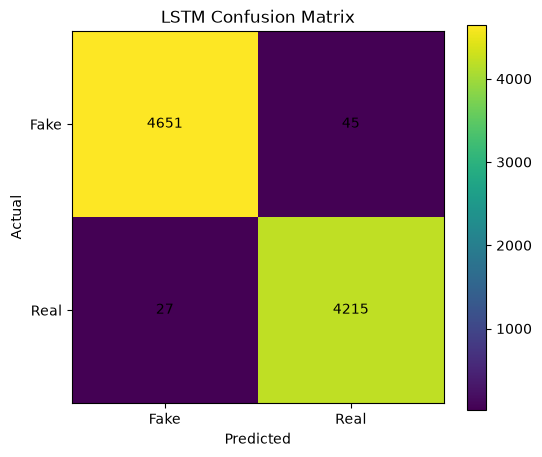

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

plt.imshow(cm)

plt.title("LSTM Confusion Matrix")

plt.colorbar()

plt.xticks(
    [0,1],
    ["Fake","Real"]
)

plt.yticks(
    [0,1],
    ["Fake","Real"]
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i,j],
            ha="center",
            va="center"
        )

plt.show()

In [44]:
model.save(
    "../models/lstm_model.keras"
)

# Summary

This notebook successfully developed and evaluated an LSTM model.

Completed tasks:

- Tokenized text
- Converted text to sequences
- Applied sequence padding
- Built an LSTM neural network
- Trained the model
- Evaluated using:
  - Accuracy
  - Precision
  - Recall
  - F1 Score
  - Confusion Matrix
- Saved the trained LSTM model

The results will be compared with the SVM model in Notebook 6.